# Libraries, Custom Functions, and Pre-Processing

- Connect to Google Drive and get access to all the files and folders. This can help us read the json for timelines and review it.
- Google Maps Timeline data wil be used to make the needed custom timeline for only the specifc days of the trip/travel.
- Also using the 'openrouteservice' library which is helping to route a driving or hiking patch with the coordinates we get on from google.

In [6]:
import os

route_api_key = os.getenv("OPENROUTE_KEY")        # OPENROUTE_KEY is the API key from OpenRouteSource website (https://openrouteservice.org/)

## Custom Functions

- Google Maps Timelines gives the coordinate data in a single string sometimes so a function 'get_latlong' is defined to produce individual latitude and longitude.
- Google timeline provides data by time and coordinate, which can be mapped as a straight line, but will ignore routing from the actual available roads for driving and hiking.
- 'openrouteservice' and its routing function is used to break these coordinates into list of multiple cordinate to make lines which can snap to existing maps.
    - A custom parameter for driving or hiking is passed.
    - Some activites tend to pass hiking coordinates to the driving instruction and a higher radius (1200 meters) is being used to compensate for searching enarest roads them.
    - The output received has many coordinates which need to be organized into a list before returning them.

In [ ]:
import openrouteservice

def get_latlong(lat_long):
    # split the string on the comma
    splitted_data = lat_long.split(",")
    # remove the degree signs to return lattitude and longitude
    lat = round(float(splitted_data[0][:-1]),6)
    lon = round(float(splitted_data[-1][:-1]),6)

    return lat, lon

# Initialize the OpenRouteService client
openroute_client = openrouteservice.Client(key=route_api_key)

def getRoute_forBatch(waypoints_list, driving_profile=True):

    if driving_profile:
        curr_profile = 'driving-car'
    else:
        curr_profile = 'foot-hiking'

    # Request a route from the API
    route = openroute_client.directions(
        coordinates = waypoints_list,
        profile = curr_profile,
        format = 'geojson',
        instructions = False,
        radiuses = 1200
    )
    coordinates = route['features'][0]['geometry']['coordinates']

    return coordinates

## Pre-Procesing

- Only using the data between 8th August and 16th August which were my travel dates for the trip
    - These are kept in UTC for now as my trip spanned across two different timezones.
    - Some activities had to be reviewed manually to set the start and end dates.
    - Checking was done by comparing the activity coordinates manually on google to confirm what the best datetime to be used.
    - Extra check is added by checking the end time with start and end datetime for activity to avoid overlapping activities as defined in the next section.
- Google Maps Timeline
    - Data is divided into 4 types - Visits, Activities, Timeline Paths, and Timeline Memory
    - **Visit**: Usually stores when you have been static on the map for a while, unsure how this works fully as it tends to capture highway stops but misses some restaurant visits. Connectivty could be a factor.
    - **Activity**: While movement is detected, google tries to predict if you were driving, walking, cycling, etc. This provides info on strat and end coordinates along with distace - so speed is a factor used to determine activity type. Again bad connectivity could factor in for error.
    - **Timeline Paths**: While activities only store the start and end coordinates along with their time, Timeline Paths store a dictionary of coordinates between those times to give a full picture of points visited usually captured at a frequency of few minutes.
    - **Timeline Memory** - My data contained very little of these for me to make any concrete definition for them and they have not been used in the analysis.
- Each row in JSON data can depict either of the above types and need a check to fill in an NA values to make their identification easier.


In [7]:
from datetime import datetime
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt

# read the JSON file
with open('data/Timeline_backup_20241002.json') as json_data:
    data = json.load(json_data)
    df_timelines = pd.json_normalize(data['semanticSegments'])

# PRE_PROCESSING

# replace any null values for columns being used
df_timelines['timelinePath'] = df_timelines['timelinePath'].fillna(0)
df_timelines['visit.probability'] = df_timelines['visit.probability'].fillna(0)
df_timelines['activity.probability'] = df_timelines['activity.probability'].fillna(0)

# convert to datetime format
df_timelines['startTime'] = pd.to_datetime(df_timelines['startTime'], utc=True)
df_timelines['endTime'] = pd.to_datetime(df_timelines['endTime'], utc=True)

# filter only for the needed travel dates
travel_start_date = '2024-08-08 16:00:00'
travel_end_date = '2024-08-16 05:30:00'

df_timelines = df_timelines[df_timelines['startTime'] >= pd.to_datetime(travel_start_date, utc=True)]
df_timelines = df_timelines[df_timelines['startTime'] <= pd.to_datetime(travel_end_date, utc=True)]
df_timelines = df_timelines[df_timelines['endTime'] <= pd.to_datetime(travel_end_date, utc=True)]

# reset the index before finalized the data frame
df_timelines = df_timelines.reset_index(drop=True)

# Processing Timelines to Trip data for Leaflet

In [18]:
import time

# PROCESSING TO MAKE FINAL CSV

trip_list = []
API_limit = 50
API_cord = []
API_cord_temp = []
activity_profile_driving = True
info_type = "Driving"

for index, df in df_timelines.iterrows():

    # for non-timelinePath - mostly only used for Visits and NOT Activites
    if df['timelinePath'] == 0:
        if not df['visit.probability'] == 0:
            if df["visit.hierarchyLevel"] == 0:
                trip_list.append(("Visit", df.startTime, df.endTime, lat, lon, df["visit.topCandidate.placeId"]))
        elif not df['activity.probability'] == 0:
            if df['activity.topCandidate.type'] == 'IN_PASSENGER_VEHICLE':
                info_type = "Driving"
                activity_profile_driving = True
            else:
                info_type = "Hiking"
                activity_profile_driving = False
    else:
        for i in range(len(df['timelinePath'])):

            # since timelinePath only have the current time - add the end time as the start of the next record
            if i == len(df['timelinePath'])-1:
                predicted_end_time = df['endTime']
            else:
                predicted_end_time = pd.to_datetime(df['timelinePath'][i+1]['time'], utc=True)

            # extract (lat,lon) infomration from the available path point
            lat, lon = get_latlong(df['timelinePath'][i]['point'])
            API_cord.append([lon, lat])        # openrouteservices expects data in long/lat format

            if len(API_cord) >= API_limit or (i == len(df['timelinePath'])-1 and len(API_cord)>1):
                print('Running ',index, ' out of ', df_timelines.shape[0])
                API_cord_temp = getRoute_forBatch(API_cord, activity_profile_driving)
                time.sleep(2)
                for temp_cord in API_cord_temp:
                    # make a tuple which can be later converted to a dataframe
                    trip_list.append((info_type, pd.to_datetime(df['timelinePath'][i]['time'], utc=True), predicted_end_time, temp_cord[1], temp_cord[0], ""))
                API_cord = [API_cord[-1]]


df_trip = pd.DataFrame(trip_list, columns=('type', 'startTime', 'endTime', 'latitude', 'longitude', 'description'))
df_trip.to_csv("trip_timeline_new.csv")

Running  0  out of  202
Running  2  out of  202
Running  6  out of  202
Running  14  out of  202
Running  14  out of  202
Running  15  out of  202
Running  15  out of  202
Running  18  out of  202
Running  25  out of  202
Running  26  out of  202
Running  29  out of  202
Running  30  out of  202
Running  30  out of  202
Running  34  out of  202
Running  34  out of  202
Running  37  out of  202
Running  41  out of  202
Running  41  out of  202
Running  48  out of  202
Running  49  out of  202
Running  54  out of  202
Running  58  out of  202
Running  64  out of  202
Running  66  out of  202
Running  67  out of  202
Running  72  out of  202
Running  72  out of  202
Running  75  out of  202
Running  81  out of  202
Running  82  out of  202
Running  85  out of  202
Running  86  out of  202
Running  89  out of  202
Running  94  out of  202
Running  94  out of  202
Running  97  out of  202
Running  98  out of  202
Running  100  out of  202
Running  102  out of  202
Running  105  out of  202


# Reviewing Google Maps Timelines data to process

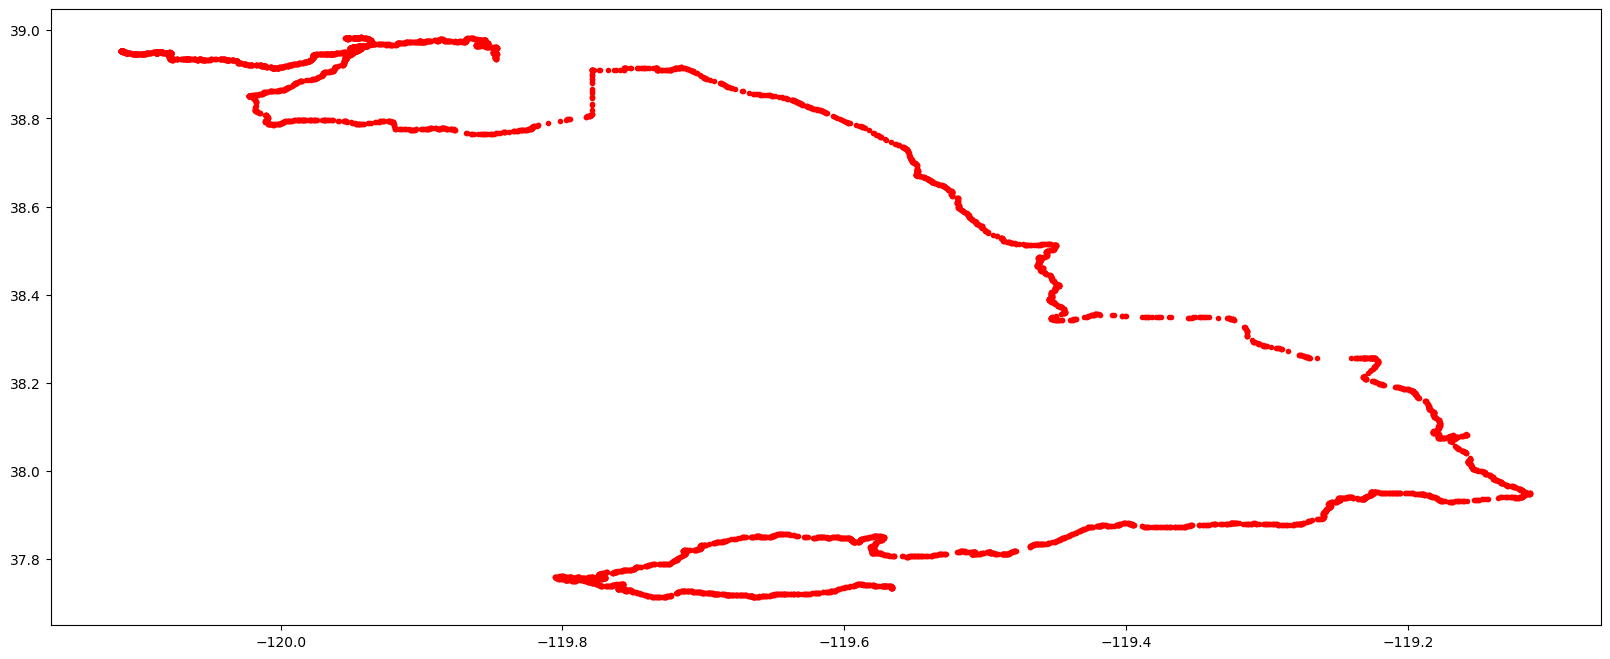

(6490, 2)


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20,8))
# skipping the activity data - as it helps oto consolidate the timelinepath with information like travel mode
for i, df_temp in df_cord.iterrows():
    plt.plot(df_temp['longitude'],df_temp['latitude'],color='red', ls='-', marker='.')

plt.show()
print(df_cord.shape)

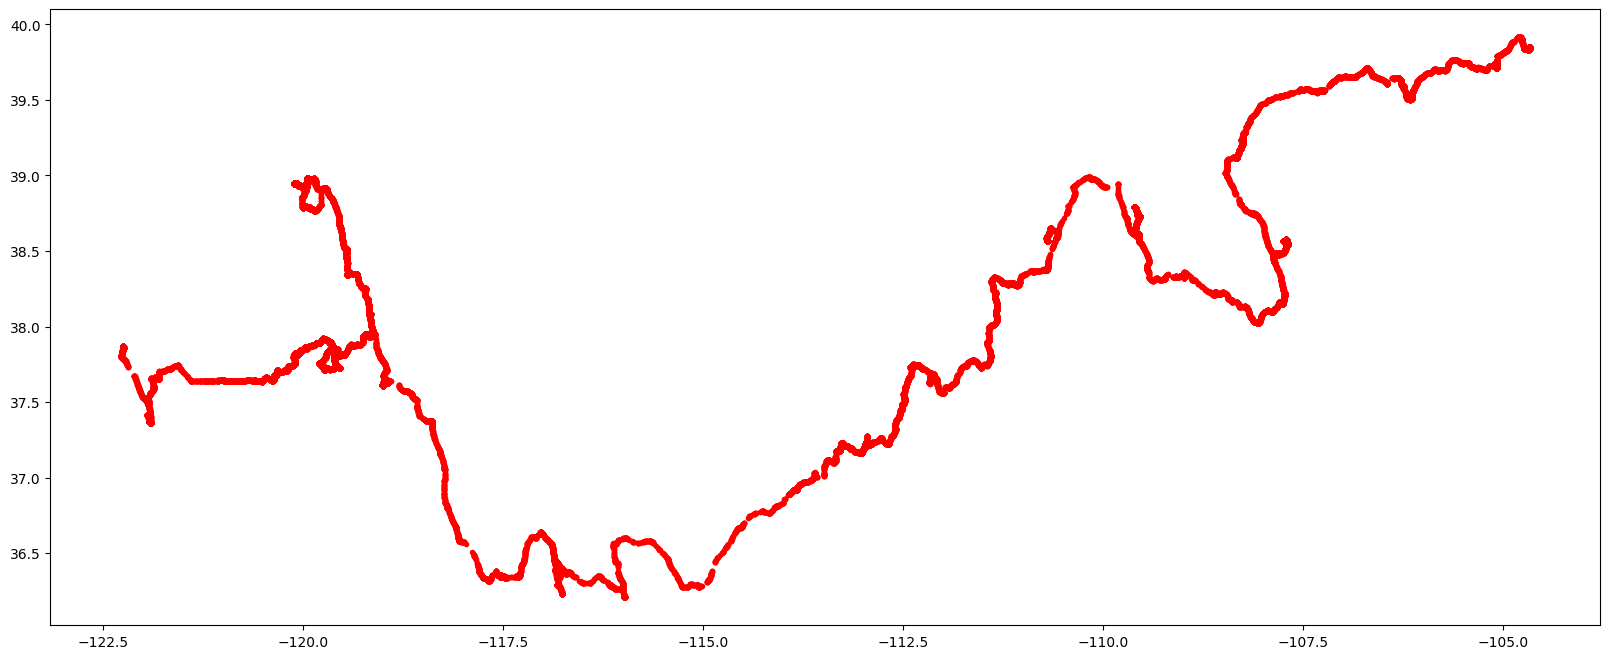

(48247, 6)


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20,8))
# skipping the activity data - as it helps oto consolidate the timelinepath with information like travel mode
for i, df_temp in df_trip.iterrows():
    plt.plot(df_temp['longitude'],df_temp['latitude'],color='red', ls='-', marker='.')

plt.show()
print(df_trip.shape)

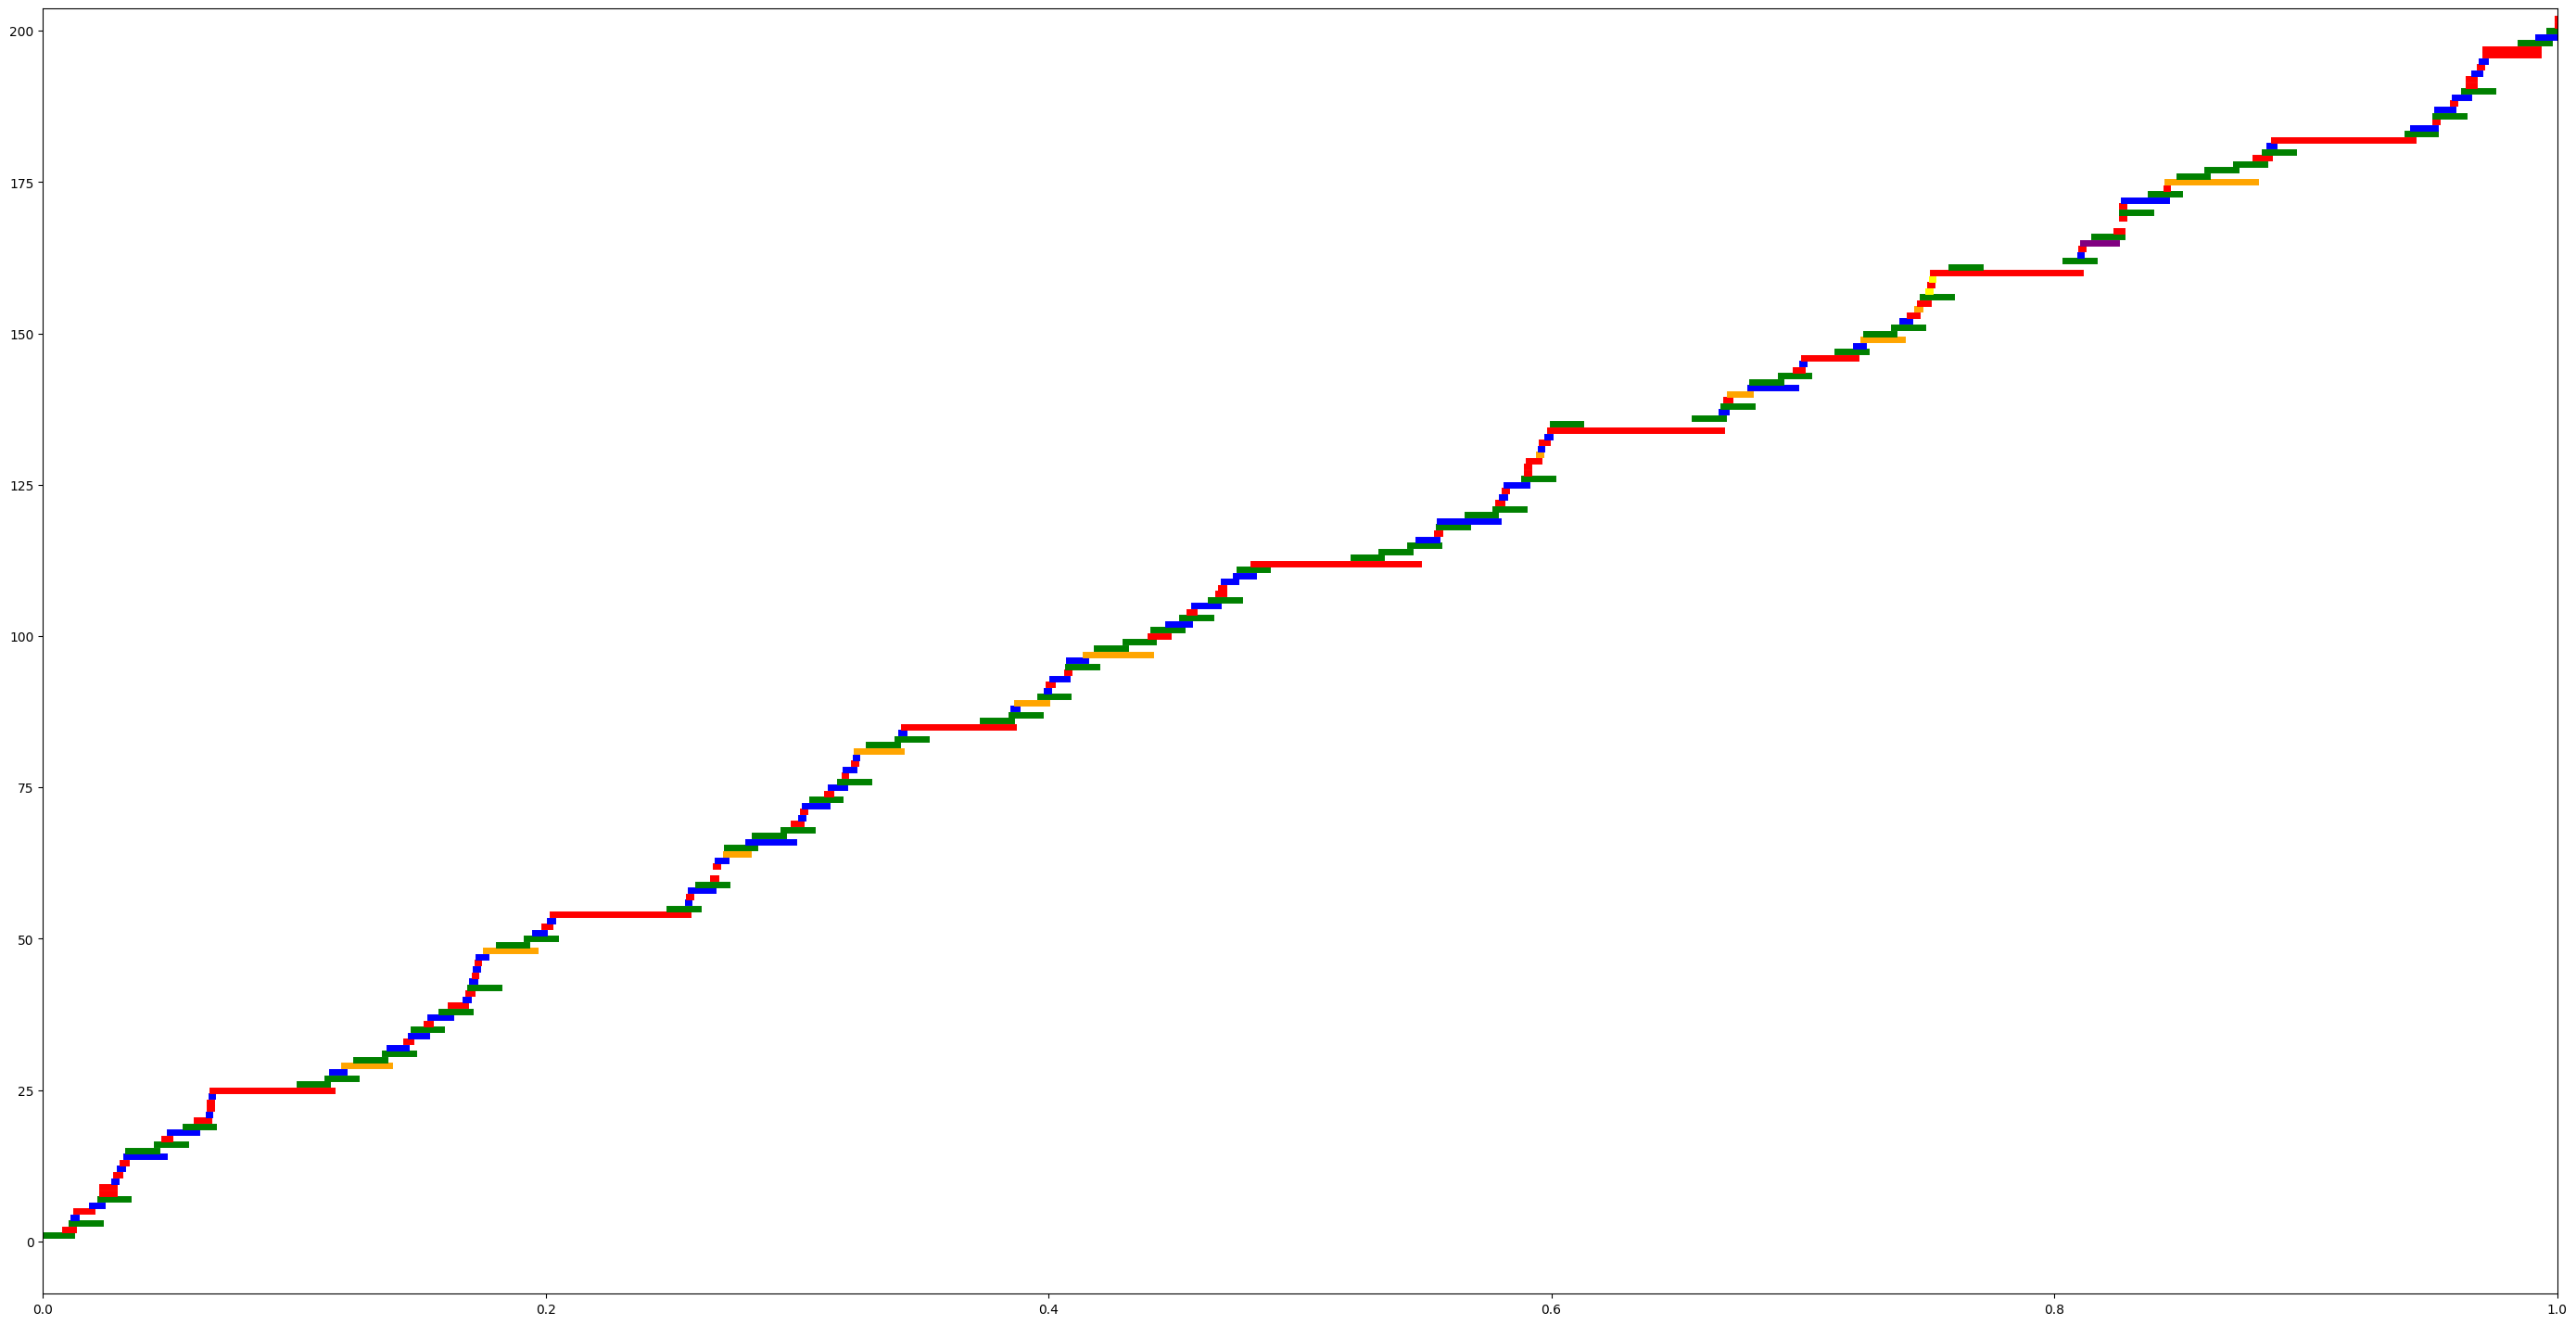

In [ ]:
import calendar

minmin = calendar.timegm(df_timelines['startTime'].iloc[0].timetuple())
maxmax = calendar.timegm(df_timelines['startTime'].iloc[-1].timetuple()) - minmin

plt.figure(figsize=(35,18))

color_dict = {
    'WALKING' : 'orange',
    'IN_PASSENGER_VEHICLE' : 'blue',
    'SKIING' : 'purple',
    'CYCLING' : 'yellow'
}

for i in range(len(df_timelines)):
    x_min = (calendar.timegm(df_timelines['startTime'].iloc[i].timetuple()) - minmin) / maxmax
    x_max = (calendar.timegm(df_timelines['endTime'].iloc[i].timetuple()) - minmin) / maxmax

    col = 'g'
    if df_timelines['timelinePath'].iloc[i] == 0:
        if not df_timelines['visit.probability'].iloc[i] == 0:
            col = 'r'
        else:
            col = color_dict[df_timelines['activity.topCandidate.type'].iloc[i]]

    plt.axhline(y = i + 1, xmin = x_min, xmax = x_max, color = col, linestyle = '-', linewidth=5)

plt.show()

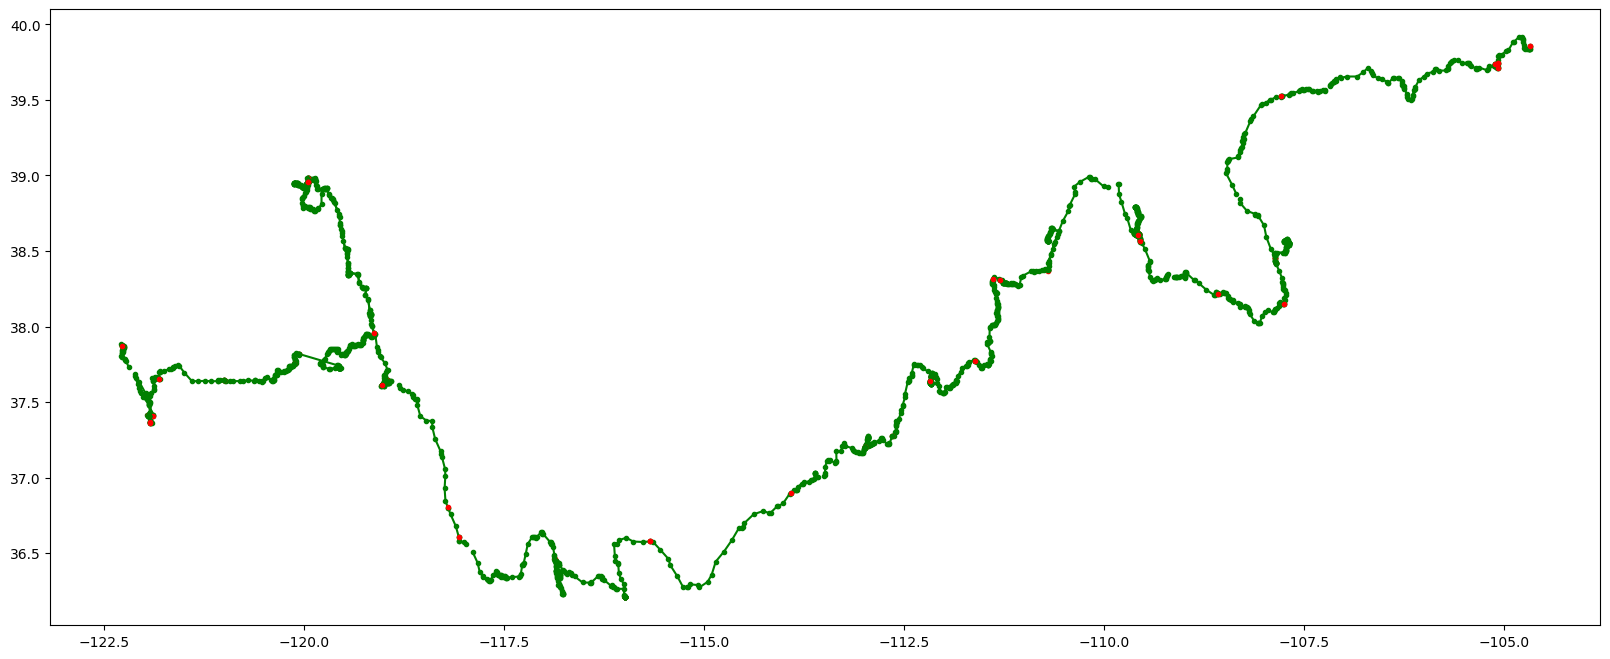

In [ ]:
def get_latlong(lat_long):
    splitted_data = lat_long.split(",")
    # flip the cordinates so E/W corresponds to x-axis while N/S to y-axis
    return float(splitted_data[-1][:-1]), float(splitted_data[-2][:-1])

def plot_timelinePath(timeline_path):
    x = []
    y = []
    for temp in timeline_path :
        t1, t2 = get_latlong(temp['point'])
        x.append(t1)
        y.append(t2)

    plt.plot(x,y,color='green', ls='-', marker='.')

plt.figure(figsize=(20,8))
# skipping the activity data - as it helps oto consolidate the timelinepath with information like travel mode
for i in range(12,222):
    if df_timelines['timelinePath'].iloc[i] == 0:
        if not df_timelines['visit.probability'].iloc[i] == 0:
            x,y = get_latlong(df_timelines['visit.topCandidate.placeLocation.latLng'].iloc[i])
            plt.plot(x,y,color='red', ls='-', marker='.')
    else:
        plot_timelinePath(df_timelines['timelinePath'].iloc[i])

plt.show()

# Image processing

In [ ]:
def getGPSInfo_fromImage(GPSInfo_dict):
    lat_dir = GPSInfo_dict[1]
    lat = GPSInfo_dict[2]
    lon_dir = GPSInfo_dict[3]
    lon = GPSInfo_dict[4]

    lat = round(float(lat[0] + lat[1]/60 + lat[2]/3600),6)
    if lat_dir == 'S':
        lat = lat * (-1)

    lon = round(float(lon[0] + lon[1]/60 + lon[2]/3600),6)
    if lon_dir == 'W':
        lon = lon * (-1)

    return lat, lon

In [ ]:
from PIL import Image
from PIL.ExifTags import TAGS, GPSTAGS
import pandas as pd

# Your image path
directory = 'direct_downloads'
scaling_factor = 2
image_info = []

# get the GPS info ID from TAGS
GPSINFO_TAG = next(
    tag for tag, name in TAGS.items() if name == "GPSInfo"
)  # should be 34853

for filename in os.listdir(directory):\

    # Open the image file
    image = Image.open(directory + '/' + filename)

    # resize and save the images to reduce size
    width, height = image.size
    new_image = image.resize((int(width/scaling_factor),int(height/scaling_factor)))
    new_image.save('final_images/' + filename)

    # Make a collection of properties and values corresponding to your image.
    lat, lon = getGPSInfo_fromImage(image._getexif()[GPSINFO_TAG])

    # make the list which will be eventually converted to a df and saved as csv
    image_info.append((filename, lat, lon))

df_imageinfo = pd.DataFrame(image_info, columns=('filename', 'latitude', 'longitude'))
df_imageinfo.to_csv("trip_imageinfo.csv")